In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import matplotlib.pyplot as plt


In [2]:
# ---------------------------------------------------------------------
# 1.  Load dataset 
# ---------------------------------------------------------------------
merged_df = pd.read_csv("../data/processed/full_nba_with_elo_538.csv")
merged_df = pd.DataFrame(merged_df)


In [3]:
merged_df.columns

Index(['game_id', 'date_game', 'team_id_main', 'team_abbreviation_main',
       'team_city_name_main', 'team_nickname_main', 'team_wins_losses_main',
       'pts_qtr1_main', 'pts_qtr2_main', 'pts_qtr3_main', 'pts_qtr4_main',
       'pts_ot1_main', 'pts_ot2_main', 'pts_ot3_main', 'pts_ot4_main',
       'pts_ot5_main', 'pts_ot6_main', 'pts_ot7_main', 'pts_ot8_main',
       'pts_ot9_main', 'pts_ot10_main', 'pts_main', 'team_name_main',
       'matchup_main', 'wl_main', 'fgm_main', 'fga_main', 'fg_pct_main',
       'fg3m_main', 'fg3a_main', 'fg3_pct_main', 'ftm_main', 'fta_main',
       'ft_pct_main', 'oreb_main', 'dreb_main', 'reb_main', 'ast_main',
       'stl_main', 'blk_main', 'tov_main', 'pf_main', 'plus_minus_main',
       'video_available_main', 'team_id_opp', 'team_abbreviation_opp',
       'team_city_name_opp', 'team_nickname_opp', 'team_wins_losses_opp',
       'pts_qtr1_opp', 'pts_qtr2_opp', 'pts_qtr3_opp', 'pts_qtr4_opp',
       'pts_ot1_opp', 'pts_ot2_opp', 'pts_ot3_opp', 'pts

In [4]:

keep_columns = ['game_id', 'date_game', 'team_id_main', 'team_abbreviation_main',
       'team_wins_losses_main',
       'pts_main',
       'matchup_main', 'wl_main', 'fgm_main', 'fga_main', 'fg_pct_main',
       'fg3m_main', 'fg3a_main', 'fg3_pct_main', 'ftm_main', 'fta_main',
       'ft_pct_main', 'oreb_main', 'dreb_main', 'ast_main',
       'stl_main', 'blk_main', 'tov_main', 'pf_main', 'plus_minus_main',
       'team_id_opp', 'team_abbreviation_opp',
       'team_wins_losses_opp',
       'pts_opp', 'team_name_opp',
       'matchup_opp', 'wl_opp', 'fgm_opp', 'fga_opp', 'fg_pct_opp', 'fg3m_opp',
       'fg3a_opp', 'fg3_pct_opp', 'ftm_opp', 'fta_opp', 'ft_pct_opp',
       'oreb_opp', 'dreb_opp', 'reb_opp', 'ast_opp', 'stl_opp', 'blk_opp',
       'tov_opp', 'pf_opp', 'plus_minus_opp', 'season_id',  
       'is_playoffs', 'elo_main_pre_538', 'elo_main_post_538', 'win_equiv',
       'elo_opp_pre_538', 'elo_opp_post_538', 'game_result', 'forecast']
merged_df = merged_df[keep_columns]

In [5]:
# ---------------------------------------------------------------------
# 2.  Inspect missing values 
# ---------------------------------------------------------------------

# Count missing values and percentages per column
missing_per_column = merged_df.isnull().sum()
missing_percentage = (missing_per_column / len(merged_df)) * 100
missing_info = pd.DataFrame({
    'missing_values': missing_per_column,
    'missing_percentage': missing_percentage
})
print("Missing values per column and missing percentage:\n", missing_info)


Missing values per column and missing percentage:
                         missing_values  missing_percentage
game_id                              0            0.000000
date_game                            0            0.000000
team_id_main                         0            0.000000
team_abbreviation_main               0            0.000000
team_wins_losses_main                0            0.000000
pts_main                             0            0.000000
matchup_main                         0            0.000000
wl_main                              0            0.000000
fgm_main                            13            0.018837
fga_main                         15856           22.975049
fg_pct_main                      15904           23.044600
fg3m_main                        13980           20.256759
fg3a_main                        19212           27.837830
fg3_pct_main                     19433           28.158055
ftm_main                            14            0.020286
fta_m


Dates with missing values:
 0        1946-11-02
1        1946-11-02
2        1946-11-05
3        1946-11-07
4        1946-11-07
            ...    
48757    1993-11-13
48771    1993-11-18
48783    1993-11-20
48959    1994-01-12
52261    1998-03-04
Name: date_game, Length: 19650, dtype: object


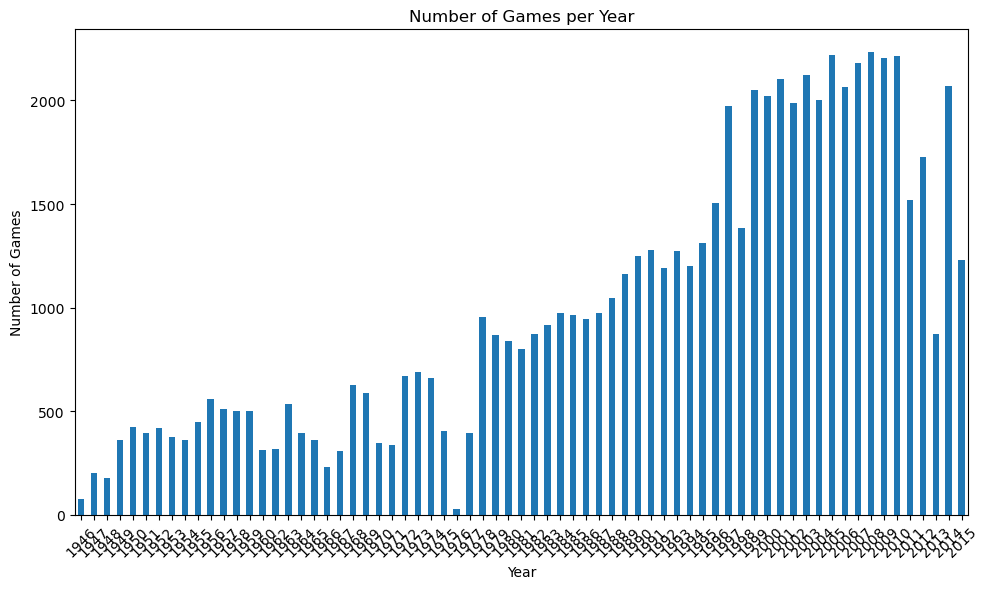

In [6]:

# Find the date when data is missing
missing_dates = merged_df[merged_df.isnull().any(axis=1)]['date_game']
print("\nDates with missing values:\n", missing_dates)

# Create a histogram of missing values based on the game date
plt.figure(figsize=(10, 6))
merged_df['date_game'] = pd.to_datetime(merged_df['date_game'])
merged_df['date_game'].dt.year.value_counts().sort_index().plot(kind='bar')
plt.title('Number of Games per Year')
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.xticks(rotation=45)
plt.tight_layout()

In [7]:
# ---------------------------------------------------------------------
# 3.  Remove rows with missing values and remove duplicate rows
# ---------------------------------------------------------------------

# Remove rows with any missing values
no_missing_df = merged_df.dropna()
# Remove duplicate rows
# cleaned_df = no_missing_df.iloc[::2]

len(no_missing_df)
no_missing_df['date_game'].min()


Timestamp('1981-05-05 00:00:00')

In [8]:
# ---------------------------------------------------------------------
# 4.  Compare old and new datasets
# ---------------------------------------------------------------------

print("The number of rows in the original dataset is ", len(merged_df))
print("The earliest game in the original dataset is ", merged_df['date_game'].min() )

print("The number of rows in the cleaned dataset is ", len(no_missing_df) )
print("The earliest game in the cleaned dataset is ", no_missing_df['date_game'].min() )

The number of rows in the original dataset is  69014
The earliest game in the original dataset is  1946-11-02 00:00:00
The number of rows in the cleaned dataset is  49364
The earliest game in the cleaned dataset is  1981-05-05 00:00:00


In [9]:
# ---------------------------------------------------------------------
# 5.  Inspect data types
# ---------------------------------------------------------------------

# Inspect data types of each column
data_types = no_missing_df.dtypes
print("\nData types of each column:\n", data_types)


Data types of each column:
 game_id                            int64
date_game                 datetime64[ns]
team_id_main                       int64
team_abbreviation_main            object
team_wins_losses_main             object
pts_main                         float64
matchup_main                      object
wl_main                           object
fgm_main                         float64
fga_main                         float64
fg_pct_main                      float64
fg3m_main                        float64
fg3a_main                        float64
fg3_pct_main                     float64
ftm_main                         float64
fta_main                         float64
ft_pct_main                      float64
oreb_main                        float64
dreb_main                        float64
ast_main                         float64
stl_main                         float64
blk_main                         float64
tov_main                         float64
pf_main                     

In [10]:
no_missing_df.head(-10)

,game_id,date_game,team_id_main,team_abbreviation_main,team_wins_losses_main,pts_main,matchup_main,wl_main,fgm_main,fga_main,...,plus_minus_opp,season_id,is_playoffs,elo_main_pre_538,elo_main_post_538,win_equiv,elo_opp_pre_538,elo_opp_post_538,game_result,forecast
7827,48000048,1981-05-05,1610612738,BOS,1-0,98.0,BOS vs. HOU,W,41.0,95.0,...,-3,41980,1,1667.9180,1670.2980,58.218166,1573.3342,1570.9542,W,0.754010
7828,48000049,1981-05-07,1610612745,HOU,1-1,92.0,BOS vs. HOU,L,41.0,82.0,...,2,41980,1,1570.9542,1579.6813,49.713020,1670.2980,1661.5709,W,0.240943
7829,48000050,1981-05-09,1610612738,BOS,2-1,94.0,HOU vs. BOS,L,24.0,79.0,...,23,41980,1,1661.5709,1680.8596,59.120193,1579.6813,1560.3926,W,0.473961
7830,48000051,1981-05-10,1610612745,HOU,2-2,91.0,HOU vs. BOS,W,37.0,103.0,...,-5,41980,1,1560.3926,1567.9680,48.532677,1680.8596,1673.2842,W,0.470580
7831,48000052,1981-05-12,1610612738,BOS,3-2,109.0,BOS vs. HOU,W,41.0,94.0,...,-29,41980,1,1673.2842,1681.8857,59.206707,1567.9680,1559.3665,W,0.765288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68999,41400226,2015-05-15,1610612744,GSW,4-2,108.0,GSW @ MEM,W,41.0,81.0,...,-13,42014,1,1777.6378,1787.3469,66.383080,1618.0546,1608.3455,W,0.584916
69000,41400237,2015-05-17,1610612746,LAC,3-4,100.0,LAC @ HOU,L,41.0,92.0,...,13,42014,1,1704.4277,1694.5431,59.496117,1659.6552,1669.5398,L,0.421184
69001,41400311,2015-05-19,1610612745,HOU,0-1,106.0,HOU @ GSW,L,40.0,86.0,...,4,42014,1,1669.5398,1667.1479,57.136570,1787.3469,1789.7388,L,0.222043
69002,41400301,2015-05-20,1610612739,CLE,1-0,97.0,CLE @ ATL,W,37.0,84.0,...,-8,42014,1,1678.9756,1689.2529,59.051449,1613.9390,1603.6616,W,0.449853


In [11]:
# Save the cleaned DataFrame to a new CSV file
output_path = Path("../data/processed/no_missing_538_kaggle_nba.csv")
no_missing_df.to_csv(output_path, index=False)